# Lake analysis


## Setup


In [1]:
import os, re
import numpy as np
import pandas as pd
import analysis_lib as A
from analysis_lib import (
    MORL_METHODS, MOEA_METHODS, ORDER,
    METHOD_LABEL, PARADIGM_OF, PARADIGM_COLOR, N_OBJS_DEFAULT,
)

N_OBJS = N_OBJS_DEFAULT  # [2, 6]

METRICS = [
    dict(col='hv_ratio',     base='hv_ratio',
         ylabel='HV (normalised)',      better='higher'),
    dict(col='spacing_norm', base='spacing_norm',
         ylabel='spacing (normalised)', better='lower'),
]

## Deterministic


### Configuration


In [2]:
MORL_CSV = '../data/lake/deterministic/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/lake/deterministic/moea/metrics_long_reeval.csv'
OUT_DIR  = './lake_figures'

CONDITION_STYLE = {
    'closed_loop_single':   dict(alpha=0.55, hatch=''),
    'intertemporal_single': dict(alpha=0.55, hatch=''),
    'dps_single':           dict(alpha=0.35, hatch=''),
}
CONDITION_LABEL = {
    'closed_loop_single':   'Q-table',
    'intertemporal_single': 'intertemporal',
    'dps_single':           'DPS',
}
CONDITION_ORDER = [
    'closed_loop_single', 'intertemporal_single', 'dps_single',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_single_(\d+)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)$')

def moea_fmt(groups):
    policy, algo, n_obj = groups
    return f'{policy}_single', algo, int(n_obj)

def morl_fmt(groups):
    scoring, n_obj = groups
    return 'closed_loop_single', scoring, int(n_obj)

### Load + summary


In [3]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER)

paradigm method        condition                    n_obj    n        n_dom     ±std        hv_ratio      ±std    spacing_norm      ±std
MORL     PQL-Pareto    closed_loop_single               2   10        110.1     11.6         0.50027   0.01735         0.02214   0.01259
MORL     PQL-Indicator closed_loop_single               2   10         86.8      8.5         0.47657   0.02314         0.01615   0.00742
MORL     PQL-Decomp    closed_loop_single               2   10        178.1     45.3         0.52761   0.01953         0.01977   0.01031
MOEA     NSGA-II       intertemporal_single             2   10          0.0      0.0         0.67010   0.00626         0.01417   0.00051
MOEA     NSGA-II       dps_single                       2   10          0.0      0.0         0.67275   0.00022         0.01266   0.00032
MOEA     IBEA          intertemporal_single             2   10          0.0      0.0         0.66757   0.00130         0.01445   0.00061
MOEA     IBEA          dps_single        

### Figure 1 — HV ratio + spacing (box plots)


Saved ./lake_figures/fig5_det_lake_metrics_hv_ratio.png
Saved ./lake_figures/fig5_det_lake_metrics_spacing_norm.png


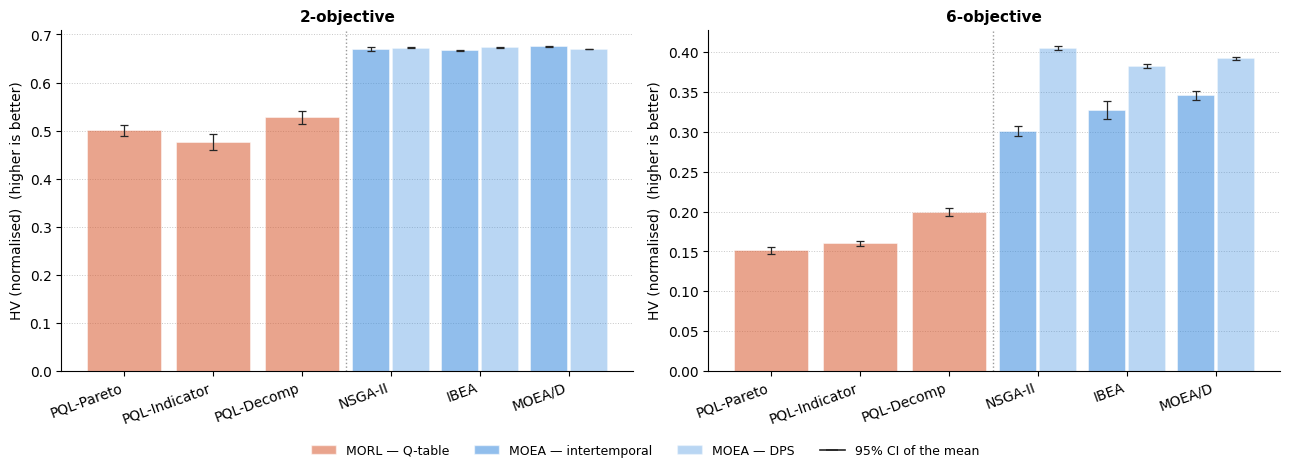

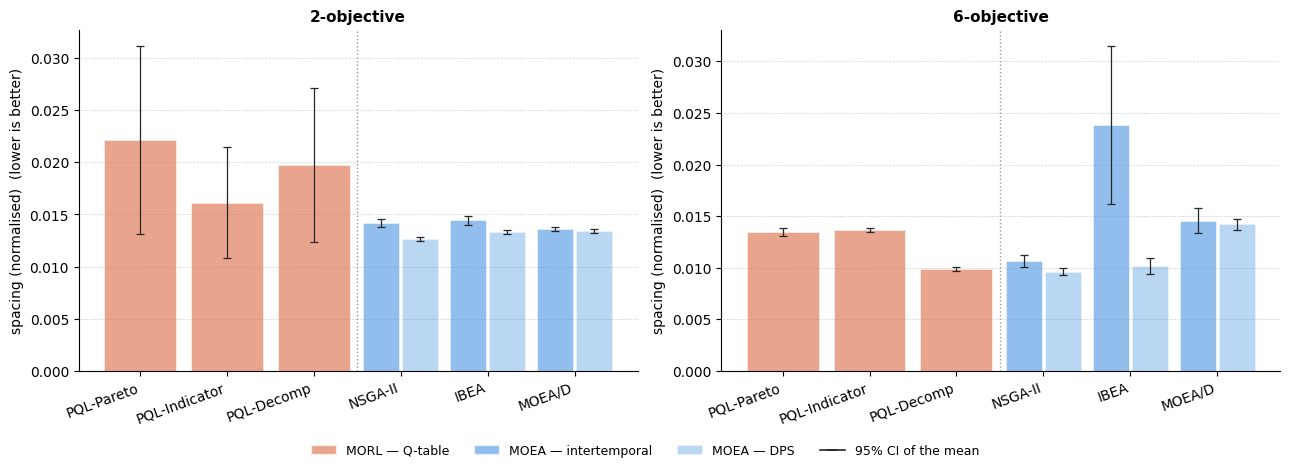

In [4]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='MORL vs MOEA — deterministic lake (closed-loop)',
    out_path=os.path.join(OUT_DIR, 'fig5_det_lake_metrics.png'))

### Figure 2 — Solution counts


In [5]:
# A.figure_counts(
#     df, n_objs=N_OBJS,
#     condition_style=CONDITION_STYLE,
#     condition_label=CONDITION_LABEL,
#     condition_order=CONDITION_ORDER,
#     # suptitle='Number of solutions on the re-evaluated front — '
#     #          'deterministic lake',
#     out_path=os.path.join(OUT_DIR, 'fig2_det_lake_counts.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 120 curves; MORL: 60 curves
Saved ./lake_figures/fig22_det_lake_conv_moea.png
Saved ./lake_figures/fig21_det_lake_conv_morl.png


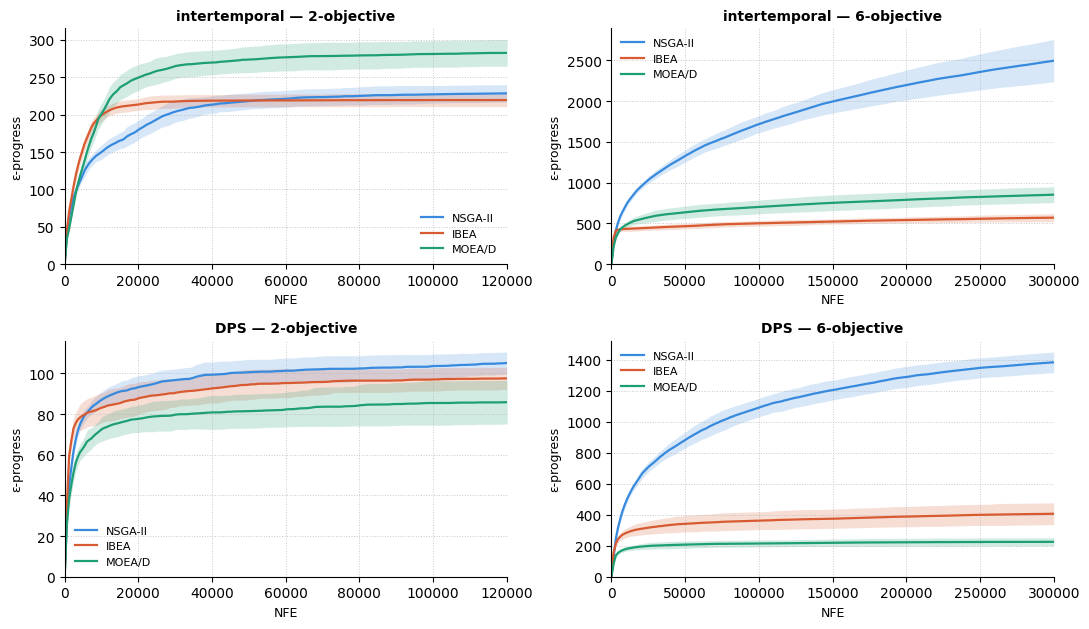

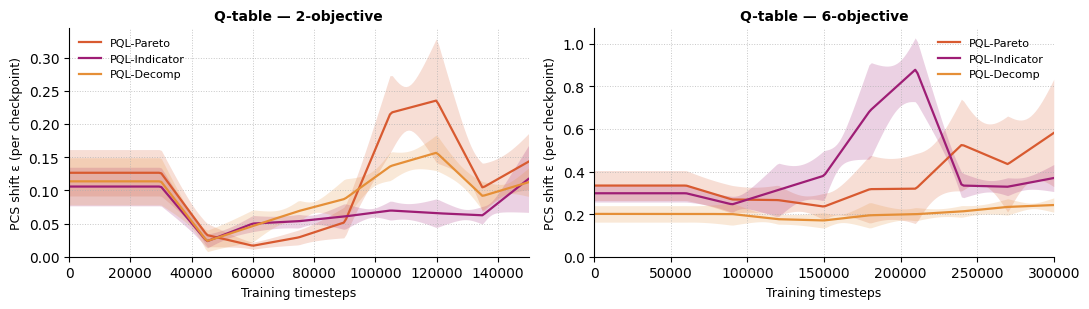

In [6]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records, methods=MOEA_METHODS,
    conditions=['intertemporal_single', 'dps_single'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — deterministic lake',
    out_path=os.path.join(OUT_DIR, 'fig22_det_lake_conv_moea.png'))

A.figure_convergence(
    morl_records, methods=MORL_METHODS,
    conditions=['closed_loop_single'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε (per checkpoint)',
    # suptitle='MORL convergence — deterministic lake',
    out_path=os.path.join(OUT_DIR, 'fig21_det_lake_conv_morl.png'))

### Runtime summary


In [7]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_file')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_file')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Deterministic lake runtime', metrics_df=df)

Total runs: 180

=== Deterministic lake runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_dom_mean,n_dom_std,n_solutions_mean,n_solutions_std
0,MOEA,IBEA,dps_single,2,10,5m09s,0m25s,51m30s,0.0,0.0,29.3,0.7
1,MOEA,IBEA,dps_single,6,10,35m32s,2m07s,5h55m20s,0.0,0.0,112.9,9.4
2,MOEA,IBEA,intertemporal_single,2,10,5m32s,0m13s,55m20s,0.0,0.0,21.7,1.3
3,MOEA,IBEA,intertemporal_single,6,10,43m25s,1m32s,7h14m10s,0.0,0.0,37.1,10.1
4,MOEA,MOEAD,dps_single,2,10,6m45s,0m24s,1h07m30s,0.0,0.0,30.5,0.7
5,MOEA,MOEAD,dps_single,6,10,19m21s,0m48s,3h13m30s,0.0,0.0,121.5,9.3
6,MOEA,MOEAD,intertemporal_single,2,10,10m24s,0m33s,1h44m00s,0.0,0.0,29.2,0.6
7,MOEA,MOEAD,intertemporal_single,6,10,28m48s,0m53s,4h48m00s,0.0,0.0,133.2,17.4
8,MOEA,NSGAII,dps_single,2,10,1m23s,0m03s,13m50s,0.0,0.0,30.0,0.0
9,MOEA,NSGAII,dps_single,6,10,8m42s,0m28s,1h27m00s,0.0,0.0,338.3,24.8


## Robust


### Configuration


In [8]:
MORL_CSV = '../data/lake/robust/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/lake/robust/moea/metrics_long_reeval.csv'

CONDITION_STYLE = {
    'closed_loop_multi':   dict(alpha=0.55, hatch=''),
    'closed_loop_moro':    dict(alpha=0.30, hatch='..'),
    'intertemporal_multi': dict(alpha=0.55, hatch=''),
    'intertemporal_moro':  dict(alpha=0.55, hatch='..'),
    'dps_multi':           dict(alpha=0.35, hatch=''),
    'dps_moro':            dict(alpha=0.35, hatch='..'),
}
CONDITION_LABEL = {
    'closed_loop_multi':   'Q-table · multi',
    'closed_loop_moro':    'Q-table · RO',
    'intertemporal_multi': 'intertemporal · multi',
    'intertemporal_moro':  'intertemporal · RO',
    'dps_multi':           'DPS · multi',
    'dps_moro':            'DPS · RO',
}
CONDITION_ORDER = [
    'closed_loop_multi', 'closed_loop_moro',
    'intertemporal_multi', 'intertemporal_moro',
    'dps_multi', 'dps_moro',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|dps)_(NSGAII|IBEA|MOEAD)_(multi|moro)_(\d+)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_(multi|moro)_(\d+)$')

def moea_fmt(groups):
    policy, algo, scenm, n_obj = groups
    return f'{policy}_{scenm}', algo, int(n_obj)

def morl_fmt(groups):
    scoring, scenm, n_obj = groups
    return f'closed_loop_{scenm}', scoring, int(n_obj)

### Load + summary


In [9]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER)

paradigm method        condition                    n_obj    n        n_dom     ±std        hv_ratio      ±std    spacing_norm      ±std
MORL     PQL-Pareto    closed_loop_multi                2   10        622.6     33.3         0.50781   0.01527         0.00555   0.00128
MORL     PQL-Pareto    closed_loop_moro                 2   10         68.3     23.9         0.51562   0.02409         0.00771   0.00196
MORL     PQL-Indicator closed_loop_multi                2   10        582.6     25.2         0.55041   0.01868         0.00538   0.00120
MORL     PQL-Indicator closed_loop_moro                 2   10         66.6     12.2         0.54515   0.01801         0.00739   0.00125
MORL     PQL-Decomp    closed_loop_multi                2   10        866.5    107.2         0.52864   0.02021         0.00438   0.00148
MORL     PQL-Decomp    closed_loop_moro                 2   10        127.8     30.3         0.52767   0.02114         0.00532   0.00141
MOEA     NSGA-II       intertemporal_mult

### Figure 1 — HV ratio + spacing (box plots)


Saved ./lake_figures/fig6_robust_lake_metrics_hv_ratio.png
Saved ./lake_figures/fig6_robust_lake_metrics_spacing_norm.png


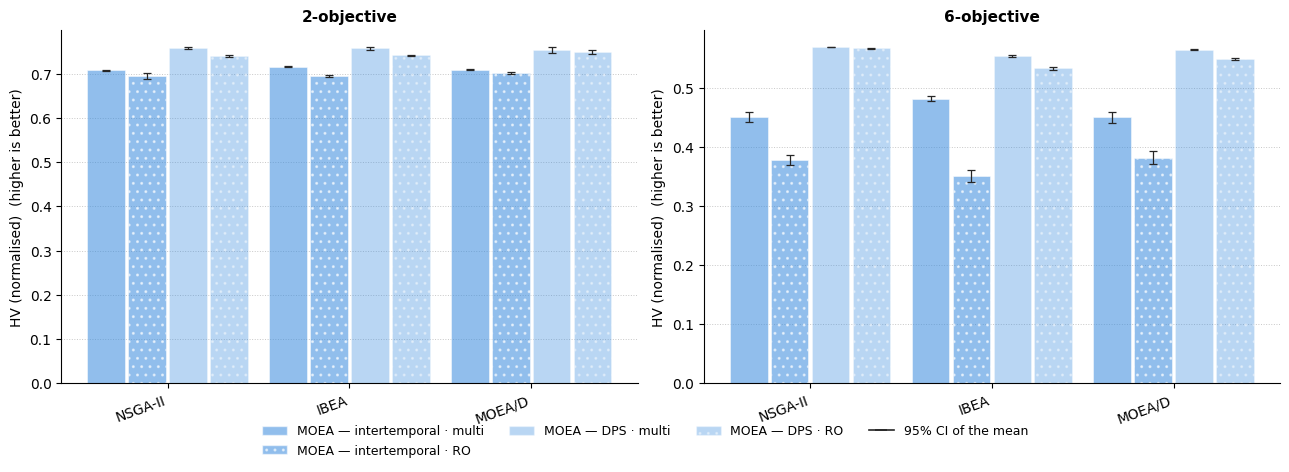

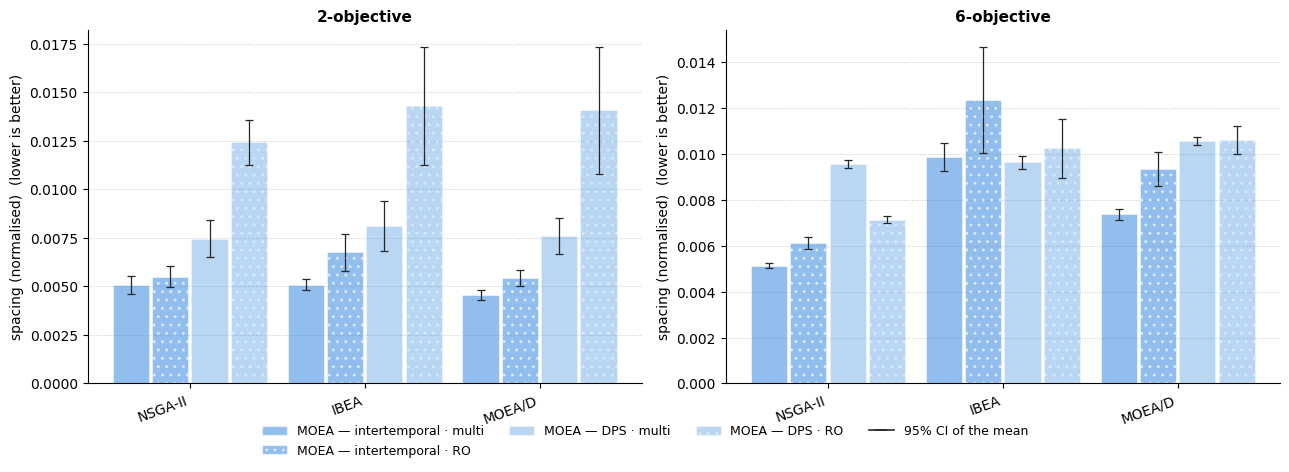

In [10]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS,
    methods=MOEA_METHODS,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    out_path=os.path.join(OUT_DIR, 'fig6_robust_lake_metrics.png'))

### Figure 2 — Solution counts


In [11]:
# A.figure_counts(
#     df, n_objs=N_OBJS,
#     condition_style=CONDITION_STYLE,
#     condition_label=CONDITION_LABEL,
#     condition_order=CONDITION_ORDER,
#     # suptitle='Number of solutions on the re-evaluated front — robust lake',
#     out_path=os.path.join(OUT_DIR, 'fig2_robust_lake_counts.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 720 curves; MORL: 360 curves
Saved ./lake_figures/fig24_robust_lake_conv_moea.png
Saved ./lake_figures/fig23_robust_lake_conv_morl.png


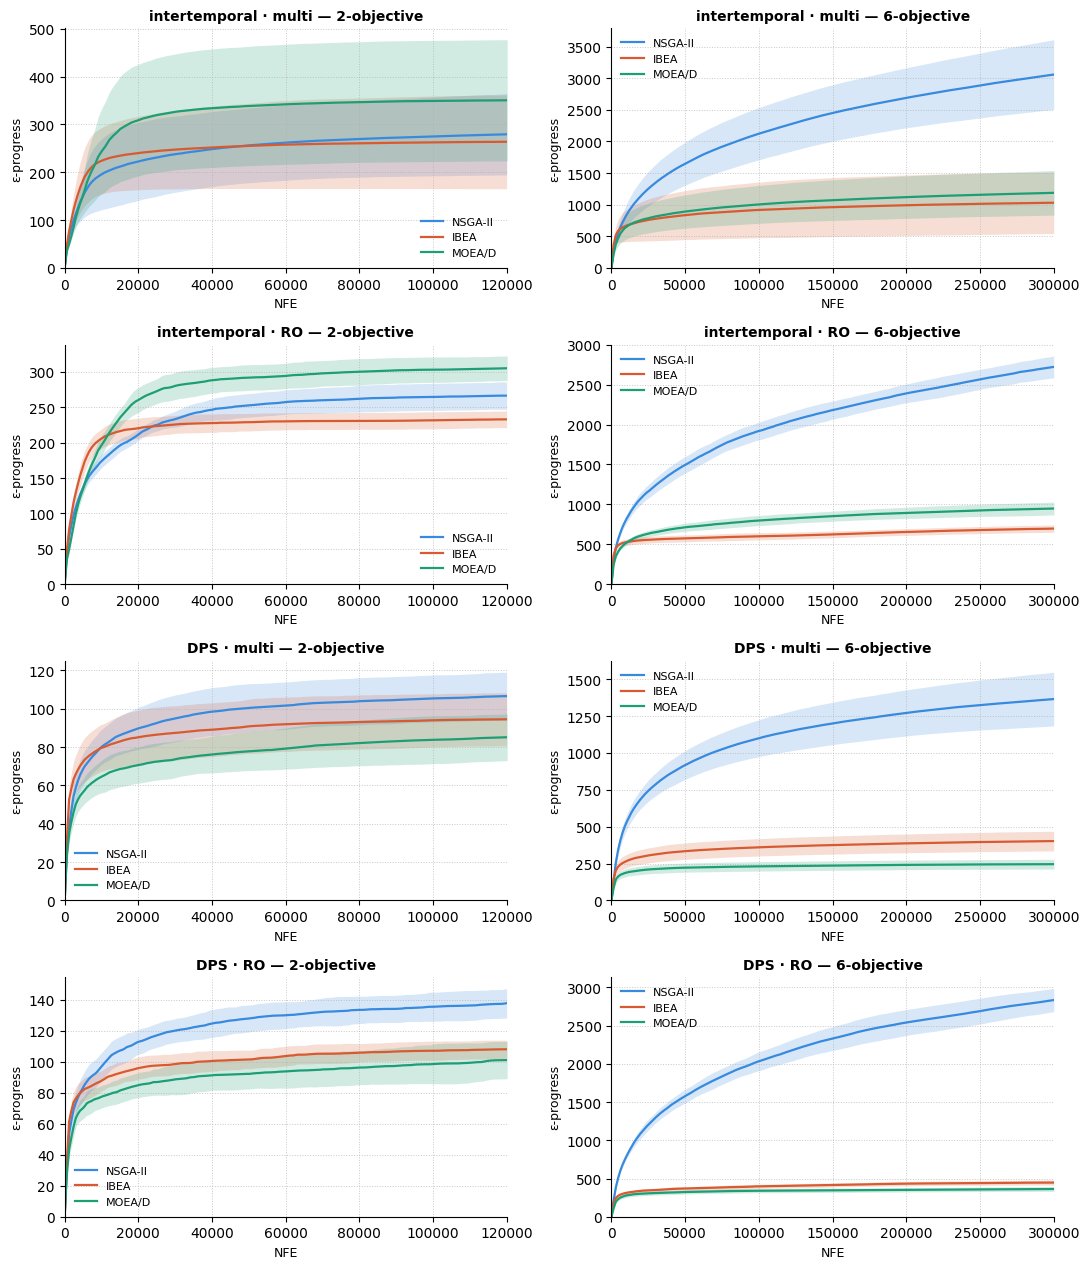

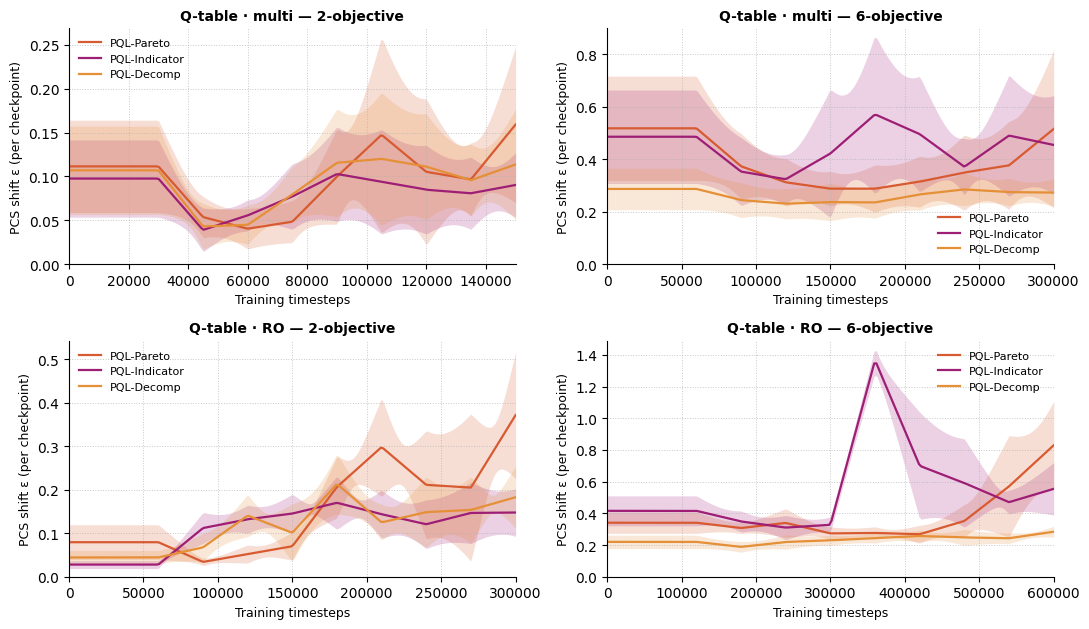

In [12]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records, methods=MOEA_METHODS,
    conditions=['intertemporal_multi', 'intertemporal_moro',
                'dps_multi', 'dps_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — robust lake',
    out_path=os.path.join(OUT_DIR, 'fig24_robust_lake_conv_moea.png'))

A.figure_convergence(
    morl_records, methods=MORL_METHODS,
    conditions=['closed_loop_multi', 'closed_loop_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε (per checkpoint)',
    # suptitle='MORL convergence — robust lake',
    out_path=os.path.join(OUT_DIR, 'fig23_robust_lake_conv_morl.png'))

### Runtime summary


In [13]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_seed')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_seed')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Robust lake runtime', metrics_df=df)

Total runs: 360

=== Robust lake runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_dom_mean,n_dom_std,n_solutions_mean,n_solutions_std
0,MOEA,IBEA,dps_moro,2,10,16m51s,1m15s,2h48m30s,9.4,1.6,17.2,1.6
1,MOEA,IBEA,dps_moro,6,10,1h11m17s,4m55s,11h52m50s,0.2,0.4,99.5,9.3
2,MOEA,IBEA,dps_multi,2,10,25m34s,1m17s,4h15m40s,111.2,4.1,45.1,3.8
3,MOEA,IBEA,dps_multi,6,10,3h05m32s,3m24s,30h55m20s,69.4,7.2,474.2,19.4
4,MOEA,IBEA,intertemporal_moro,2,10,18m16s,1m20s,3h02m40s,1.0,0.8,22.0,1.2
5,MOEA,IBEA,intertemporal_moro,6,10,1h18m43s,4m52s,13h07m10s,0.5,0.7,69.8,6.0
6,MOEA,IBEA,intertemporal_multi,2,10,28m31s,0m44s,4h45m10s,76.9,2.6,43.9,3.4
7,MOEA,IBEA,intertemporal_multi,6,10,3h39m23s,7m43s,36h33m50s,48.4,8.4,291.1,31.5
8,MOEA,MOEAD,dps_moro,2,10,17m22s,2m05s,2h53m40s,9.4,4.1,20.3,3.3
9,MOEA,MOEAD,dps_moro,6,10,50m45s,3m46s,8h27m30s,0.4,1.0,163.2,15.0
